### FineTunung=> we train the model with some own  examples for our specific domain which is nothing but train a person for the specific domain hw will work on that and to get more specialized skilled for that specialized domain during what domain we train   

### BERT Model will come to know that=>if pair of  resume and JD pair is get high match or if their keywords ar not matched we say this is low match
### and how it will differnetiate the high match resume-JD pair and low match resume-JD pair 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer, InputExample, losses
from sentence_transformers.evaluation import EmbeddingSimilarityEvaluator
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, classification_report
from sklearn.metrics.pairwise import cosine_similarity
import json, warnings
warnings.filterwarnings('ignore')

print('Libraries imported!')

Libraries imported!


In [3]:
# Load the cleaned ATS pairs dataset
df = pd.read_csv('cleaned_resumeJD_pairs.csv')
print(f'Loaded: {len(df)} pairs')
print(f'\nLabel distribution:')
print(df['match_label'].value_counts())
print(f'\nScore range: {df["match_score"].min():.2f} – {df["match_score"].max():.2f}')
df.head(3)

Loaded: 280 pairs

Label distribution:
match_label
medium    110
high       93
low        77
Name: count, dtype: int64

Score range: 0.06 – 0.94


,resume_text,job_description,match_label,match_score,match_label_lower,resume_len,jd_len
0,BI Analyst with 7 years of experience based in...,Fathom is hiring a Financial Analyst (Berlin)....,medium,0.53,medium,75,71
1,Data Scientist with 13 years of experience bas...,Lumen is hiring a Senior UX Designer (Singapor...,low,0.26,low,79,74
2,Software Engineer with 8 years of experience b...,Acme Corp is hiring a Product Manager (Seattle...,low,0.31,low,71,80


In [4]:
#Train / Val / Test Split
#Stratify by match_label so each split has balanced high/medium/low
#stratify=>keeps the same proportion of match_label classes in train, validation, and test sets.
# dataset is  first split into train of 70% and temp of 30%
train_df, temp_df = train_test_split(
    df, test_size=0.3, random_state=42, stratify=df['match_label']
)
#temp is split into validation of 15% and test of 15%
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=42, stratify=temp_df['match_label']
)

print(f'Train:      {len(train_df)} pairs')
print(f'Validation: {len(val_df)} pairs')
print(f'Test:       {len(test_df)} pairs')
print()

# Verify each split has all 3 labels
for name, split in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    print(f'{name} label dist: {split["match_label"].value_counts().to_dict()}')

Train:      196 pairs
Validation: 42 pairs
Test:       42 pairs

Train label dist: {'medium': 77, 'high': 65, 'low': 54}
Val label dist: {'medium': 16, 'high': 14, 'low': 12}
Test label dist: {'medium': 17, 'high': 14, 'low': 11}


In [5]:
#Convert to InputExample format — sentence-transformers expects this
#text1 = resume, text2 = job description, label = match_score (float 0-1)

train_examples = [
    InputExample(texts=[row['resume_text'], row['job_description']], label=float(row['match_score']))
    for _, row in train_df.iterrows() # for iterate the row
]

val_examples = [
    InputExample(texts=[row['resume_text'], row['job_description']], label=float(row['match_score']))
    for _, row in val_df.iterrows()
]

print(f'Train examples: {len(train_examples)}')
print(f'Val examples:   {len(val_examples)}')
print(f'\nSample InputExample:')
print(f'  text1 (resume): {train_examples[0].texts[0][:80]}...')
print(f'  text2 (JD):     {train_examples[0].texts[1][:80]}...')
print(f'  label:          {train_examples[0].label}')

Train examples: 196
Val examples:   42

Sample InputExample:
  text1 (resume): Site Reliability Engineer with 6 years of experience based in Toronto. M.S. in H...
  text2 (JD):     TechNova is hiring a Associate Product Manager (Seattle). In this role you will ...
  label:          0.15


In [6]:
#Base Model Baseline
print('Loading base BERT model...')
base_model = SentenceTransformer('all-mpnet-base-v2')
print('Loaded.')

Loading base BERT model...
Loaded.


In [7]:
# Evaluate base model on test set BEFORE fine-tuning
# This is our baseline, fine-tuning should beat this
print('Evaluating base model on test set...')

base_preds = []
for _, row in test_df.iterrows():#iterate the rows in test_df
    emb1 = base_model.encode(row['resume_text'])
    emb2 = base_model.encode(row['job_description'])
    sim  = cosine_similarity([emb1], [emb2])[0][0]
    base_preds.append(float(sim))
#loss
base_mae  = mean_absolute_error(test_df['match_score'], base_preds)
base_rmse = np.sqrt(mean_squared_error(test_df['match_score'], base_preds))

print(f'\nBase Model — Test Set Performance')
print(f'  MAE:  {base_mae:.4f}')
print(f'  RMSE: {base_rmse:.4f}')
print()
print('Goal: fine-tuning should reduce MAE below this number.')

Evaluating base model on test set...

Base Model — Test Set Performance
  MAE:  0.1946
  RMSE: 0.2332

Goal: fine-tuning should reduce MAE below this number.


In [8]:
#Fine-Tune BERT

# Fresh model instance for fine-tuning (don't reuse base_model)
model = SentenceTransformer('all-mpnet-base-v2')

# DataLoader, shuffles training data each epoch
train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=16)

# CosineSimilarityLoss=>this is the loss function used for both resume and JD: trains the model so that
# cosine_similarity(embed(resume), embed(jd)) ≈ match_score(this loss function will check the match score bw the resume,JD embed and match_score and this fun will adjust the model wights based on the loss)
train_loss = losses.CosineSimilarityLoss(model)

# Evaluator runs on val set after each evaluation_steps
evaluator = EmbeddingSimilarityEvaluator.from_input_examples(
    val_examples, name='ats-val'
)

print('Training setup ready.')
print(f'  Batch size:   16')
print(f'  Train pairs:  {len(train_examples)}')
print(f'  Steps/epoch:  {len(train_dataloader)}')

Training setup ready.
  Batch size:   16
  Train pairs:  196
  Steps/epoch:  13


In [9]:
# Fine-tune
# epochs=10 is reasonable for 200-250 training pairs
# warmup_steps = 10% of total steps
#!pip install datasets
from datasets import Dataset
total_steps   = len(train_dataloader) * 10
warmup_steps  = int(total_steps * 0.1)#For the first 10% of the training steps, gradually increase the learning rate instead of immediately using the full learning rate

print(f'Total steps:  {total_steps}')
print(f'Warmup steps: {warmup_steps}')
print(f'\nStarting fine-tuning...\n')
  # actual finetuning starts
model.fit(
    train_objectives=[(train_dataloader, train_loss)],
    evaluator=evaluator,
    epochs=10,
    evaluation_steps=len(train_dataloader),   # evaluate once per epoch
    warmup_steps=warmup_steps,
    output_path='models/finetuned-bert',
    save_best_model=True, # overall out of  the number of 10 epochs, the best epoch(checkpoint) is saved
    show_progress_bar=True
)

print('\nFine-tuning complete!')

Total steps:  130
Warmup steps: 13

Starting fine-tuning...



Epoch:   0%|          | 0/10 [00:00<?, ?it/s]

Iteration:   0%|          | 0/13 [00:00<?, ?it/s]

Iteration:   0%|          | 0/13 [00:00<?, ?it/s]

Iteration:   0%|          | 0/13 [00:00<?, ?it/s]

...

Iteration:   0%|          | 0/13 [00:00<?, ?it/s]

Iteration:   0%|          | 0/13 [00:00<?, ?it/s]

Iteration:   0%|          | 0/13 [00:00<?, ?it/s]

Iteration:   0%|          | 0/13 [00:00<?, ?it/s]


Fine-tuning complete!


In [10]:
#Evaluate Fine-Tuned Model which is the best checkpoint saved during finetuning that becoe the bestmodel i.e named as finetuned-bert

finetuned_model = SentenceTransformer('models/finetuned-bert')
print('Fine-tuned model loaded.')

Fine-tuned model loaded.


In [11]:
#
ft_preds = []
for _, row in test_df.iterrows():
    emb1 = finetuned_model.encode(row['resume_text'])
    emb2 = finetuned_model.encode(row['job_description'])
    sim  = cosine_similarity([emb1], [emb2])[0][0]
    ft_preds.append(float(sim))

ft_mae  = mean_absolute_error(test_df['match_score'], ft_preds)
ft_rmse = np.sqrt(mean_squared_error(test_df['match_score'], ft_preds))

print(f'\nFine-tuned Model — Test Set Performance')
print(f'  MAE:  {ft_mae:.4f}')
print(f'  RMSE: {ft_rmse:.4f}')


Fine-tuned Model — Test Set Performance
  MAE:  0.0962
  RMSE: 0.1199


In [12]:
# Side-by-side comparison
print('=' * 50)
print('MODEL COMPARISON')
print('=' * 50)
print(f'  Base MAE:         {base_mae:.4f}')
print(f'  Fine-tuned MAE:   {ft_mae:.4f}')
print(f'  Improvement:      {(base_mae - ft_mae)/base_mae*100:.1f}%')
print('=' * 50)

MODEL COMPARISON
  Base MAE:         0.1946
  Fine-tuned MAE:   0.0962
  Improvement:      50.6%


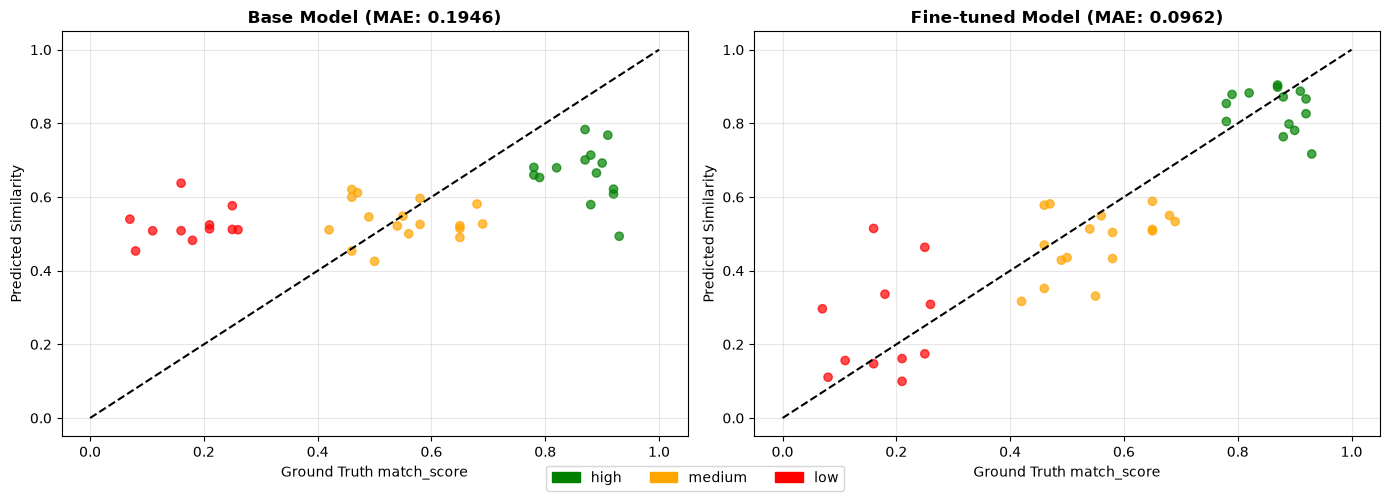

In [13]:
# Scatter plots: base vs fine-tuned
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = test_df['match_label'].map({'low':'red','medium':'orange','high':'green'})

for ax, preds, title, mae in [
    (axes[0], base_preds, 'Base Model', base_mae),
    (axes[1], ft_preds,   'Fine-tuned Model', ft_mae),
]:
    ax.scatter(test_df['match_score'], preds, c=colors, alpha=0.7)
    ax.plot([0,1],[0,1],'k--', label='Perfect')
    ax.set_xlabel('Ground Truth match_score')
    ax.set_ylabel('Predicted Similarity')
    ax.set_title(f'{title} (MAE: {mae:.4f})', fontweight='bold')
    ax.grid(True, alpha=0.3)

from matplotlib.patches import Patch
fig.legend(handles=[
    Patch(color='green', label='high'),
    Patch(color='orange', label='medium'),
    Patch(color='red', label='low'),
], loc='lower center', ncol=3)
plt.tight_layout()
plt.show()

In [14]:
metadata = {
    'base_model':       'all-mpnet-base-v2',
    'dataset':          'merged_dataset_clean.csv',
    'total_pairs':      len(df),
    'train_pairs':      len(train_df),
    'val_pairs':        len(val_df),
    'test_pairs':       len(test_df),
    'epochs':           10,
    'batch_size':       16,
    'base_mae':         round(float(base_mae), 4),
    'finetuned_mae':    round(float(ft_mae), 4),
    'improvement_pct':  round((base_mae - ft_mae) / base_mae * 100, 2),
}

with open('models/finetuned-bert/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('Saved: models/finetuned-bert/')
print(json.dumps(metadata, indent=2))

Saved: models/finetuned-bert/
{
  "base_model": "all-mpnet-base-v2",
  "dataset": "merged_dataset_clean.csv",
  "total_pairs": 280,
  "train_pairs": 196,
  "val_pairs": 42,
  "test_pairs": 42,
  "epochs": 10,
  "batch_size": 16,
  "base_mae": 0.1946,
  "finetuned_mae": 0.0962,
  "improvement_pct": 50.59
}


In [15]:
#Production Pipeline Test
#To check  how model will perform accurately
def score_resume_against_jd(resume_text, jd_text, model):
 
    emb_resume = model.encode(resume_text, convert_to_numpy=True)
    emb_jd     = model.encode(jd_text,     convert_to_numpy=True)
    score      = cosine_similarity([emb_resume], [emb_jd])[0][0]
    return float(score)


# Test with realistic cases
test_cases = [
    {
        'label':  'HIGH match expected',
        'resume': 'Senior Python developer with 6 years experience. Built REST APIs using FastAPI and Django. Proficient in PostgreSQL, Docker, and AWS deployment.',
        'jd':     'We need a Python backend engineer with FastAPI or Django experience. Must know SQL databases and cloud deployment.',
    },
    {
        'label':  'MEDIUM match expected',
        'resume': 'Frontend developer with 3 years React and TypeScript experience. Some Node.js and Express for small APIs.',
        'jd':     'Full stack engineer needed. React frontend required, strong Python backend preferred. 4+ years experience.',
    },
    {
        'label':  'LOW match expected',
        'resume': 'Executive Chef with 12 years experience in fine dining. Expert in French cuisine, menu planning, and kitchen management.',
        'jd':     'Data Scientist with Python, machine learning, and SQL experience required.',
    },
]

print('Production Pipeline Test')
print('=' * 60)
for case in test_cases:
    score = score_resume_against_jd(case['resume'], case['jd'], finetuned_model)
    label = 'HIGH' if score > 0.70 else 'MEDIUM' if score > 0.45 else 'LOW'
    print(f"\n{case['label']}")
    print(f"  Predicted score: {score:.4f}  →  {label}")

Production Pipeline Test

HIGH match expected
  Predicted score: 0.8112  →  HIGH

MEDIUM match expected
  Predicted score: 0.7701  →  HIGH

LOW match expected
  Predicted score: 0.1459  →  LOW


In [16]:
import sentence_transformers
import datasets

print("Sentence Transformers:", sentence_transformers.__version__)
print("Datasets:", datasets.__version__)

Sentence Transformers: 2.7.0
Datasets: 5.0.1
